In [1]:
import os
import cv2
import gc
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

from xgboost import XGBClassifier

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.models import Model

2026-05-17 17:09:33.332814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779037773.517575      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779037773.570676      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779037773.984516      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779037773.984558      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779037773.984560      57 computation_placer.cc:177] computation placer alr

In [4]:
# ============================================================
# LOAD CHEST X-RAY DATASET
# ============================================================

X = []
Y = []

IMG_SIZE = 64

base_dir = '../input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/'

normal_path = base_dir + 'NORMAL/'
pneumonia_path = base_dir + 'PNEUMONIA/'

# NORMAL IMAGES
for img_name in os.listdir(normal_path):

    img_path = os.path.join(normal_path, img_name)

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    X.append(img)

    Y.append(0)

# PNEUMONIA IMAGES
for img_name in os.listdir(pneumonia_path):

    img_path = os.path.join(pneumonia_path, img_name)

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    X.append(img)

    Y.append(1)

# Convert to numpy arrays
X = np.array(X, dtype='float16')

Y = np.array(Y)

# Normalize
X = X / 255.0

# Flatten images
X_flatten = X.reshape(X.shape[0], -1)

# Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(

    X_flatten,
    Y,

    test_size=0.2,

    stratify=Y,

    random_state=42
)

print("X_train_full shape :", X_train_full.shape)

print("X_test shape :", X_test.shape)

X_train_full shape : (4172, 12288)
X_test shape : (1044, 12288)



ORIGINAL XGBOOST WITH 20% DATA
Accuracy    : 0.9109
F1-Score    : 0.9423
Sensitivity : 0.9781
Specificity : 0.7164


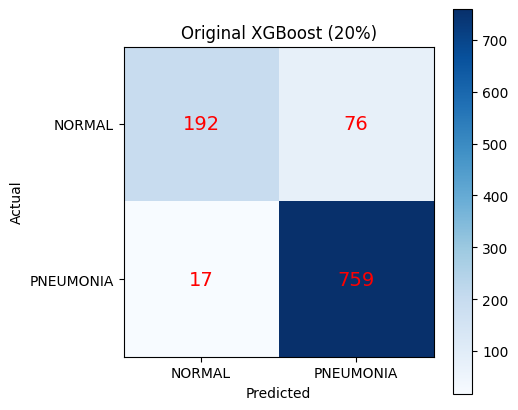


ORIGINAL XGBOOST WITH 40% DATA
Accuracy    : 0.9349
F1-Score    : 0.9573
Sensitivity : 0.9820
Specificity : 0.7985


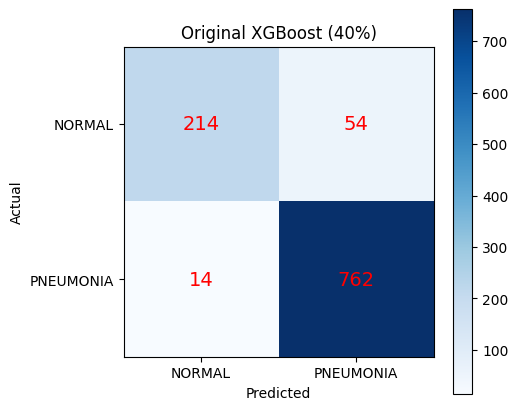


ORIGINAL XGBOOST WITH 60% DATA
Accuracy    : 0.9310
F1-Score    : 0.9547
Sensitivity : 0.9781
Specificity : 0.7948


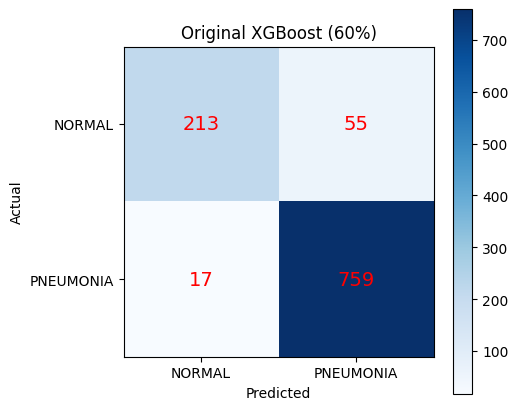


ORIGINAL XGBOOST WITH 80% DATA
Accuracy    : 0.9435
F1-Score    : 0.9626
Sensitivity : 0.9794
Specificity : 0.8396


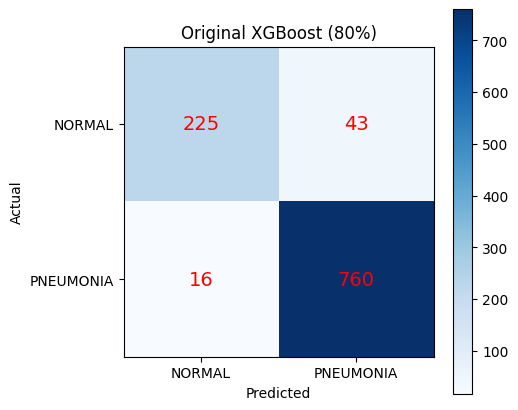

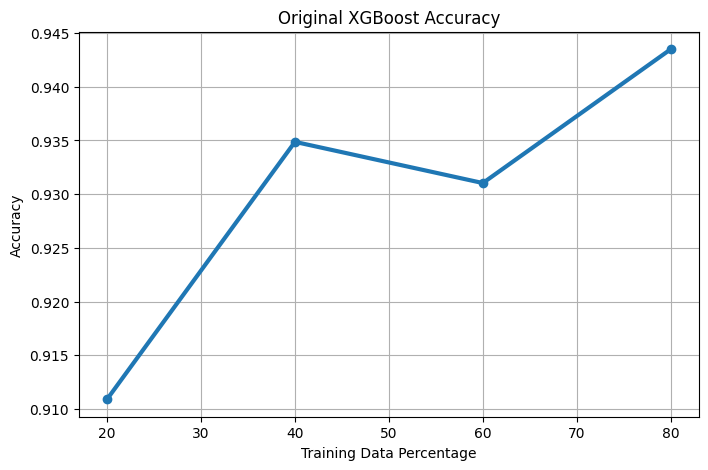

In [5]:
# ============================================================
# ORIGINAL XGBOOST
# ============================================================

percentages = [20,40,60,80]

accuracies_xgb = []

for pct in percentages:

    print("\n================================================")
    print(f"ORIGINAL XGBOOST WITH {pct}% DATA")
    print("================================================")

    subset_size = int(len(X_train_full) * (pct/100))

    X_train = X_train_full[:subset_size]

    y_train = y_train_full[:subset_size]

    # Model
    xgb_model = XGBClassifier(

        n_estimators=30,

        max_depth=6,

        learning_rate=0.1,

        objective='binary:logistic',

        eval_metric='logloss',

        random_state=42
    )

    # Train
    xgb_model.fit(X_train, y_train)

    # Predict
    y_pred = xgb_model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    TN, FP, FN, TP = cm.ravel()

    sensitivity = TP / (TP + FN)

    specificity = TN / (TN + FP)

    accuracies_xgb.append(accuracy)

    # Results
    print(f"Accuracy    : {accuracy:.4f}")

    print(f"F1-Score    : {f1:.4f}")

    print(f"Sensitivity : {sensitivity:.4f}")

    print(f"Specificity : {specificity:.4f}")

    # Confusion Matrix
    plt.figure(figsize=(5,5))

    plt.imshow(cm, cmap='Blues')

    plt.title(f'Original XGBoost ({pct}%)')

    plt.xticks([0,1], ['NORMAL','PNEUMONIA'])

    plt.yticks([0,1], ['NORMAL','PNEUMONIA'])

    for i in range(2):
        for j in range(2):

            plt.text(
                j,
                i,
                cm[i,j],
                ha='center',
                va='center',
                color='red',
                fontsize=14
            )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.colorbar()

    plt.show()

# Accuracy Plot
plt.figure(figsize=(8,5))

plt.plot(
    percentages,
    accuracies_xgb,
    marker='o',
    linewidth=3
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("Original XGBoost Accuracy")

plt.grid(True)

plt.show()


PCA + XGBOOST WITH 20% DATA
Accuracy    : 0.9042
F1-Score    : 0.9370
Sensitivity : 0.9588
Specificity : 0.7463


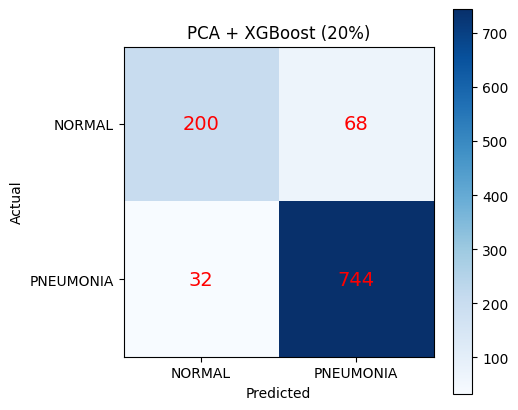


PCA + XGBOOST WITH 40% DATA
Accuracy    : 0.9215
F1-Score    : 0.9482
Sensitivity : 0.9665
Specificity : 0.7910


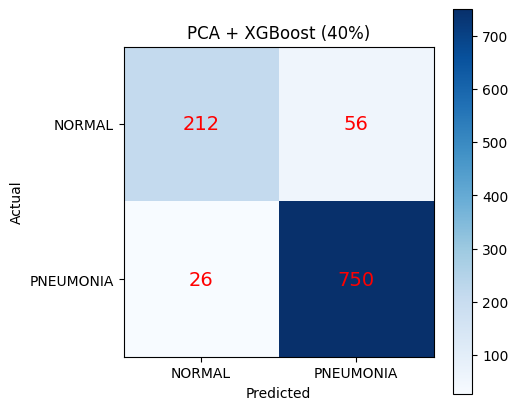


PCA + XGBOOST WITH 60% DATA
Accuracy    : 0.9330
F1-Score    : 0.9554
Sensitivity : 0.9652
Specificity : 0.8396


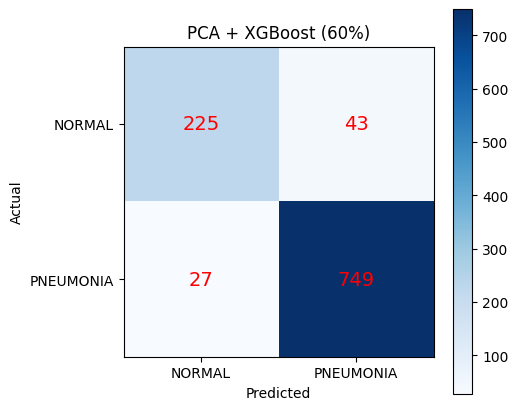


PCA + XGBOOST WITH 80% DATA
Accuracy    : 0.9253
F1-Score    : 0.9506
Sensitivity : 0.9665
Specificity : 0.8060


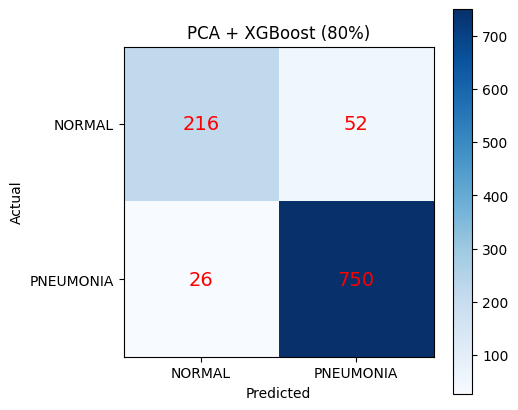

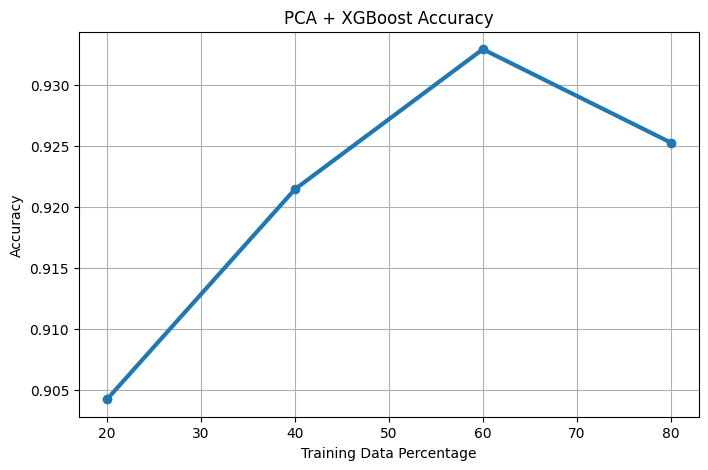

In [6]:
# ============================================================
# PCA + XGBOOST
# ============================================================

percentages = [20,40,60,80]

accuracies_pca = []

for pct in percentages:

    print("\n================================================")
    print(f"PCA + XGBOOST WITH {pct}% DATA")
    print("================================================")

    subset_size = int(len(X_train_full) * (pct/100))

    X_train = X_train_full[:subset_size]

    y_train = y_train_full[:subset_size]

    # PCA
    pca = PCA(n_components=50)

    X_train_pca = pca.fit_transform(X_train)

    X_test_pca = pca.transform(X_test)

    # Model
    pca_model = XGBClassifier(

        n_estimators=30,

        max_depth=6,

        learning_rate=0.1,

        objective='binary:logistic',

        eval_metric='logloss',

        random_state=42
    )

    # Train
    pca_model.fit(X_train_pca, y_train)

    # Predict
    y_pred_pca = pca_model.predict(X_test_pca)

    # Metrics
    accuracy_pca = accuracy_score(y_test, y_pred_pca)

    f1_pca = f1_score(y_test, y_pred_pca)

    cm_pca = confusion_matrix(y_test, y_pred_pca)

    TN, FP, FN, TP = cm_pca.ravel()

    sensitivity_pca = TP / (TP + FN)

    specificity_pca = TN / (TN + FP)

    accuracies_pca.append(accuracy_pca)

    # Results
    print(f"Accuracy    : {accuracy_pca:.4f}")

    print(f"F1-Score    : {f1_pca:.4f}")

    print(f"Sensitivity : {sensitivity_pca:.4f}")

    print(f"Specificity : {specificity_pca:.4f}")

    # Confusion Matrix
    plt.figure(figsize=(5,5))

    plt.imshow(cm_pca, cmap='Blues')

    plt.title(f'PCA + XGBoost ({pct}%)')

    plt.xticks([0,1], ['NORMAL','PNEUMONIA'])

    plt.yticks([0,1], ['NORMAL','PNEUMONIA'])

    for i in range(2):
        for j in range(2):

            plt.text(
                j,
                i,
                cm_pca[i,j],
                ha='center',
                va='center',
                color='red',
                fontsize=14
            )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.colorbar()

    plt.show()

# Accuracy Plot
plt.figure(figsize=(8,5))

plt.plot(
    percentages,
    accuracies_pca,
    marker='o',
    linewidth=3
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("PCA + XGBoost Accuracy")

plt.grid(True)

plt.show()

I0000 00:00:1779038238.623751      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1779038242.643400     137 service.cc:152] XLA service 0x7efc693671e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779038242.643442     137 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779038242.811780     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/33 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step

I0000 00:00:1779038250.488939     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 230ms/step

VGG16 + XGBOOST WITH 20% DATA
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step
Accuracy    : 0.9406
F1-Score    : 0.9609
Sensitivity : 0.9820
Specificity : 0.8209


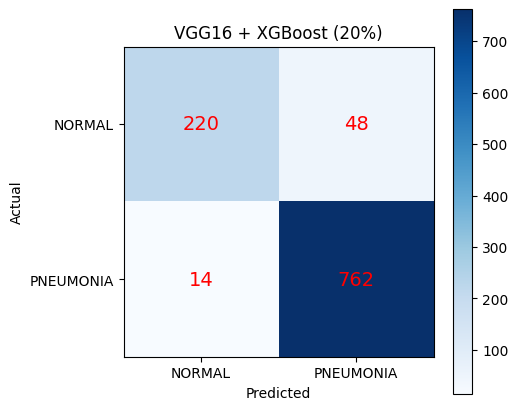


VGG16 + XGBOOST WITH 40% DATA
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step
Accuracy    : 0.9511
F1-Score    : 0.9675
Sensitivity : 0.9794
Specificity : 0.8694


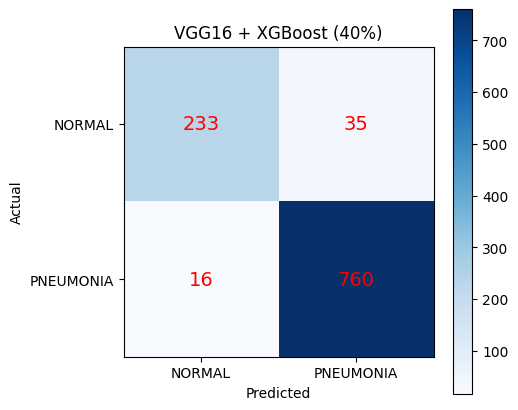


VGG16 + XGBOOST WITH 60% DATA
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step
Accuracy    : 0.9550
F1-Score    : 0.9699
Sensitivity : 0.9768
Specificity : 0.8918


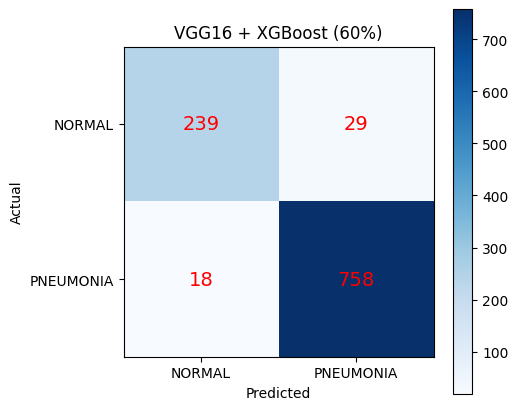


VGG16 + XGBOOST WITH 80% DATA
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step
Accuracy    : 0.9579
F1-Score    : 0.9718
Sensitivity : 0.9768
Specificity : 0.9030


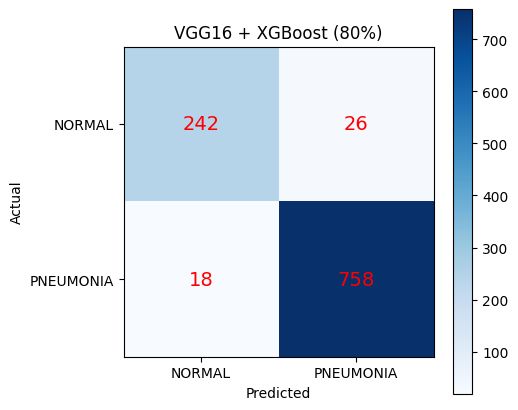

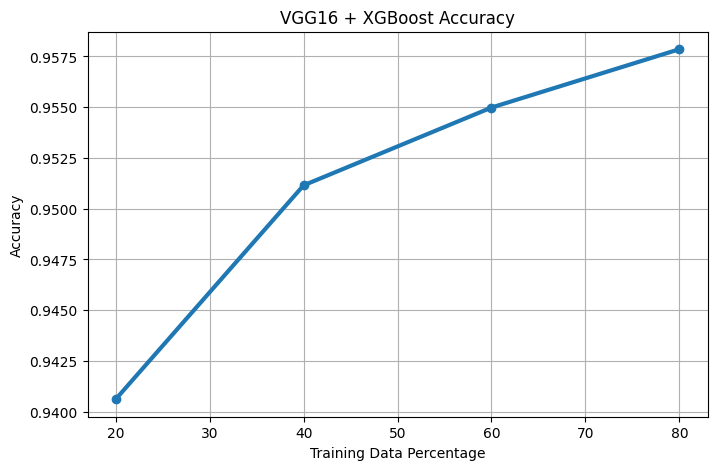

In [7]:
# ============================================================
# VGG16 + XGBOOST
# ============================================================

gc.collect()

X_vgg = []
Y_vgg = []

IMG_SIZE_VGG = 224

# NORMAL IMAGES
for img_name in os.listdir(normal_path):

    img_path = normal_path + img_name

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE_VGG, IMG_SIZE_VGG))

    img = preprocess_input(img)

    X_vgg.append(img)

    Y_vgg.append(0)

# PNEUMONIA IMAGES
for img_name in os.listdir(pneumonia_path):

    img_path = pneumonia_path + img_name

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE_VGG, IMG_SIZE_VGG))

    img = preprocess_input(img)

    X_vgg.append(img)

    Y_vgg.append(1)

X_vgg = np.array(X_vgg, dtype='float16')

Y_vgg = np.array(Y_vgg)

# Split
X_train_vgg_full, X_test_vgg, y_train_vgg_full, y_test_vgg = train_test_split(

    X_vgg,
    Y_vgg,

    test_size=0.2,

    stratify=Y_vgg,

    random_state=42
)

# ============================================================
# LOAD VGG16 MODEL
# ============================================================

base_model = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

feature_extractor = Model(

    inputs=base_model.input,

    outputs=base_model.output
)

# Extract test features once
test_features = feature_extractor.predict(X_test_vgg)

test_features = test_features.reshape(
    test_features.shape[0],
    -1
)

percentages = [20,40,60,80]

accuracies_vgg = []

for pct in percentages:

    print("\n================================================")
    print(f"VGG16 + XGBOOST WITH {pct}% DATA")
    print("================================================")

    subset_size = int(len(X_train_vgg_full) * (pct/100))

    X_train_vgg = X_train_vgg_full[:subset_size]

    y_train_vgg = y_train_vgg_full[:subset_size]

    # Extract Features
    train_features = feature_extractor.predict(X_train_vgg)

    train_features = train_features.reshape(
        train_features.shape[0],
        -1
    )

    # Model
    vgg_model = XGBClassifier(

        n_estimators=30,

        max_depth=6,

        learning_rate=0.1,

        objective='binary:logistic',

        eval_metric='logloss',

        random_state=42
    )

    # Train
    vgg_model.fit(train_features, y_train_vgg)

    # Predict
    y_pred_vgg = vgg_model.predict(test_features)

    # Metrics
    accuracy_vgg = accuracy_score(y_test_vgg, y_pred_vgg)

    f1_vgg = f1_score(y_test_vgg, y_pred_vgg)

    cm_vgg = confusion_matrix(y_test_vgg, y_pred_vgg)

    TN, FP, FN, TP = cm_vgg.ravel()

    sensitivity_vgg = TP / (TP + FN)

    specificity_vgg = TN / (TN + FP)

    accuracies_vgg.append(accuracy_vgg)

    # Results
    print(f"Accuracy    : {accuracy_vgg:.4f}")

    print(f"F1-Score    : {f1_vgg:.4f}")

    print(f"Sensitivity : {sensitivity_vgg:.4f}")

    print(f"Specificity : {specificity_vgg:.4f}")

    # Confusion Matrix
    plt.figure(figsize=(5,5))

    plt.imshow(cm_vgg, cmap='Blues')

    plt.title(f'VGG16 + XGBoost ({pct}%)')

    plt.xticks([0,1], ['NORMAL','PNEUMONIA'])

    plt.yticks([0,1], ['NORMAL','PNEUMONIA'])

    for i in range(2):
        for j in range(2):

            plt.text(
                j,
                i,
                cm_vgg[i,j],
                ha='center',
                va='center',
                color='red',
                fontsize=14
            )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.colorbar()

    plt.show()

# Accuracy Plot
plt.figure(figsize=(8,5))

plt.plot(
    percentages,
    accuracies_vgg,
    marker='o',
    linewidth=3
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("VGG16 + XGBoost Accuracy")

plt.grid(True)

plt.show()